<a href="https://colab.research.google.com/github/clobos/ECO5056_2026/blob/main/ECO5056_Semana01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar bibliotecas de Python

Esta célula é responsável por importar todas as bibliotecas e módulos Python necessários para a execução do restante do notebook. Cada importação serve a um propósito específico:

*   `pandas as pd`: Essencial para manipulação e análise de dados tabulares, principalmente com DataFrames.

*   `seaborn as sns`: Utilizado para visualização estatística de dados e para carregar conjuntos de dados de exemplo, como o `penguins`.

*   `sklearn.model_selection.train_test_split`: Função para dividir o conjunto de dados em subconjuntos de treino e teste, o que é fundamental para avaliar o desempenho do modelo de forma justa.

*   `sklearn.compose.ColumnTransformer`: Ferramenta para aplicar diferentes transformações a diferentes colunas do DataFrame, um passo crucial no pré-processamento de dados heterogêneos.

*   `sklearn.pipeline.Pipeline`: Usado para encadear múltiplas etapas de processamento de dados e modelagem em uma única sequência, simplificando o fluxo de trabalho.

*   `sklearn.impute.SimpleImputer`: Usado para preencher valores ausentes nos dados, seja com a média, mediana, moda ou um valor constante.

*   `sklearn.preprocessing.OneHotEncoder`: Converte variáveis categóricas em um formato numérico binário (one-hot encoding), que é compreendido pela maioria dos algoritmos de machine learning.

*   `sklearn.ensemble.RandomForestClassifier`: O algoritmo de machine learning escolhido para a tarefa de classificação, que constrói várias árvores de decisão e combina suas previsões.

*   `sklearn.metrics`: Contém diversas funções para avaliar a qualidade e o desempenho do modelo, incluindo acurácia, relatório de classificação e matriz de confusão.

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score,classification_report, ConfusionMatrixDisplay)

# Carregamento dos Dados e Definição de Variáveis
Esta célula tem como objetivo carregar o conjunto de dados que será utilizado e separar as características (variáveis de entrada) da variável alvo (variável que queremos prever).

*   `dados = sns.load_dataset("penguins")`: Carrega o conjunto de dados 'Palmer Penguins', um dataset popular para classificação, diretamente da biblioteca `seaborn` para um DataFrame do pandas chamado `dados`.
*   `variaveis = [...]`: Define uma lista de strings que contém os nomes das colunas que serão consideradas como características (features) para o modelo. Estas são as informações que o modelo usará para fazer as previsões.
*   `X = dados[variaveis]`: Cria um novo DataFrame `X` que inclui apenas as colunas especificadas em `variaveis`. Este `X` representa as variáveis independentes do nosso modelo.
*   `y = dados["species"]`: Cria uma Series `y` contendo a coluna 'species'. Esta é a variável dependente, ou seja, o que o modelo tentará prever (as diferentes espécies de pinguins: Adelie, Chinstrap, Gentoo).

In [2]:
# Carrega o dataset Palmer Penguins (seaborn)
dados = sns.load_dataset("penguins")

variaveis = ["island", "bill_length_mm", "bill_depth_mm",
    "flipper_length_mm", "body_mass_g", "sex"]
X = dados[variaveis]
y = dados["species"]  # Adelie, Chinstrap, Gentoo

# Visualização das Primeiras Linhas de X

Esta célula simples é usada para inspecionar as primeiras linhas do DataFrame `X` (as características). Isso ajuda a verificar se os dados foram carregados corretamente e se as colunas selecionadas estão presentes e com o formato esperado.

*   `print(X.head())`: Exibe as cinco primeiras linhas do DataFrame `X`. `head()` é uma função muito útil para uma rápida visualização dos dados.

In [3]:
print(X.head())

      island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0  Torgersen            39.1           18.7              181.0       3750.0   
1  Torgersen            39.5           17.4              186.0       3800.0   
2  Torgersen            40.3           18.0              195.0       3250.0   
3  Torgersen             NaN            NaN                NaN          NaN   
4  Torgersen            36.7           19.3              193.0       3450.0   

      sex  
0    Male  
1  Female  
2  Female  
3     NaN  
4  Female  


# Estatísticas Descritivas de X

Esta célula fornece um resumo estatístico das colunas numéricas do DataFrame `X`.

*   `X.describe()`: Gera um conjunto de estatísticas descritivas para cada coluna numérica em `X`. Isso inclui:
    *   `count`: O número de valores não nulos.
    *   `mean`: A média dos valores.
    *   `std`: O desvio padrão, indicando a dispersão dos dados.
    *   `min`: O valor mínimo.
    *   `25%`, `50%` (mediana), `75%`: Os quartis, que mostram a distribuição dos dados.
    *   `max`: O valor máximo.

Estas estatísticas são cruciais para entender a distribuição, a centralidade e a variabilidade dos dados numéricos, além de identificar possíveis valores atípicos ou a presença de valores ausentes.

In [4]:
X.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


# Visualização das Primeiras Linhas de y

Esta célula é similar à que visualiza `X.head()`, mas foca na variável alvo `y`.

*   `print(y.head())`: Exibe as cinco primeiras entradas da Series `y` (a coluna 'species'). Isso permite verificar o formato e os valores da variável que o modelo tentará prever.

In [5]:
print(y.head())

0    Adelie
1    Adelie
2    Adelie
3    Adelie
4    Adelie
Name: species, dtype: object


# Contagem de Valores da Variável Alvo `y`

Esta célula é importante para entender a distribuição das classes na variável alvo.

*   `y.value_counts()`: Retorna uma Series que mostra a contagem de cada valor único (cada espécie de pinguim) presente na variável `y`. Isso é crucial para verificar se o dataset está balanceado (tem uma quantidade similar de amostras para cada classe) ou desbalanceado. O balanceamento das classes pode influenciar o desempenho do modelo, e essa visualização ajuda a identificar se estratégias para lidar com desbalanceamento serão necessárias.

In [6]:
y.value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


# Divisão Estratificada dos Dados

Esta célula é fundamental no fluxo de trabalho de machine learning, pois divide o conjunto de dados em partes para treinamento e teste, garantindo que a proporção das classes seja mantida.

*   `X_treino, X_teste, y_treino, y_teste = train_test_split(...)`:
    *   `X, y`: São os DataFrames de características e a Series alvo que serão divididos.
    *   `test_size=0.25`: Indica que 25% do conjunto de dados será reservado para teste, enquanto os 75% restantes serão usados para treinar o modelo.
    *   `stratify=y`: Este é um parâmetro muito importante para problemas de classificação. Ele garante que a proporção das classes (neste caso, as espécies de pinguins) seja a mesma nos conjuntos de `y_treino` e `y_teste` que a proporção no `y` original. Isso evita que o conjunto de teste tenha uma representação desproporcional de uma classe, o que poderia levar a uma avaliação tendenciosa do modelo.
    *   `random_state=42`: Define uma "semente" para o gerador de números aleatórios. Usar um `random_state` fixo garante que a divisão dos dados seja sempre a mesma cada vez que o código é executado, tornando os resultados reproduzíveis e comparáveis.

In [11]:
# Divisão estratificada: mantém proporção de espécies
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

# Visualização das Primeiras Linhas de X_treino
Após a divisão dos dados, é uma boa prática inspecionar os conjuntos resultantes. Esta célula mostra as primeiras entradas do conjunto de características de treino.

*   `print(X_treino.head())`: Exibe as cinco primeiras linhas do DataFrame `X_treino`, que contém as características dos dados que serão usados para treinar o modelo de machine learning.

In [ ]:
print(X_treino.head())

        island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
291     Biscoe            46.4           15.6              221.0       5000.0   
144      Dream            37.3           16.8              192.0       3000.0   
212      Dream            51.9           19.5              206.0       3950.0   
45       Dream            39.6           18.8              190.0       4600.0   
78   Torgersen            36.2           16.1              187.0       3550.0   

        sex  
291    Male  
144  Female  
212    Male  
45     Male  
78   Female  


# Visualização das Primeiras Linhas de X_teste

Esta célula, análoga à anterior, mostra as primeiras entradas do conjunto de características de teste.

*   `print(X_teste.head())`: Exibe as cinco primeiras linhas do DataFrame `X_teste`, que contém as características dos dados que serão usados para avaliar o desempenho do modelo após o treinamento (o modelo nunca "viu" esses dados durante o treino).

In [ ]:
print( X_teste.head())

     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
236  Biscoe            42.0           13.5              210.0       4150.0   
230  Biscoe            40.9           13.7              214.0       4650.0   
151   Dream            41.5           18.5              201.0       4000.0   
173   Dream            48.5           17.5              191.0       3400.0   
174   Dream            43.2           16.6              187.0       2900.0   

        sex  
236  Female  
230  Female  
151    Male  
173    Male  
174  Female  


# Visualização das Primeiras Linhas de y_treino

Esta célula permite verificar as primeiras entradas da variável alvo para o conjunto de treino.

*   `print(y_treino.head())`: Exibe as cinco primeiras etiquetas de `y_treino`, que são as espécies de pinguins correspondentes aos dados em `X_treino`.

In [ ]:
print( y_treino.head())

291       Gentoo
144       Adelie
212    Chinstrap
45        Adelie
78        Adelie
Name: species, dtype: object


# Visualização das Primeiras Linhas de y_teste

Similar às visualizações anteriores, esta célula mostra as primeiras entradas da variável alvo para o conjunto de teste.

*   `print(y_teste.head())`: Exibe as cinco primeiras etiquetas de `y_teste`, que são as espécies de pinguins correspondentes aos dados em `X_teste`. Essas são as "respostas corretas" que serão comparadas com as previsões do modelo.

In [ ]:
print(y_teste.head())

236       Gentoo
230       Gentoo
151       Adelie
173    Chinstrap
174    Chinstrap
Name: species, dtype: object


# Tabela de Frequência para y_treino

Esta célula exibe a distribuição das classes (espécies de pinguins) no conjunto de dados de treino.

*   `print("Tabela de Frequência para y_treino:")`: Simplesmente imprime um cabeçalho para clareza.
*   `print(y_treino.value_counts())`: Usa o método `value_counts()` para contar a ocorrência de cada espécie em `y_treino`. Esta verificação é importante para confirmar que a divisão estratificada (`stratify=y` no `train_test_split`) funcionou corretamente, garantindo que o conjunto de treino tenha uma representação proporcional de cada classe.

In [12]:
print("Tabela de Frequência para y_treino:")
print(y_treino.value_counts())


Tabela de Frequência para y_treino:
species
Adelie       114
Gentoo        93
Chinstrap     51
Name: count, dtype: int64


# Tabela de Frequência para y_teste

Similar à célula anterior, esta célula exibe a distribuição das classes no conjunto de dados de teste.

*   `print("\nTabela de Frequência para y_teste:")`: Imprime um cabeçalho para o resultado.
*   `print(y_teste.value_counts())`: Conta a ocorrência de cada espécie em `y_teste`. Comparar esta contagem com a de `y_treino` e com o `y` original ajuda a confirmar a efetividade da estratificação na manutenção das proporções de classe, o que é vital para uma avaliação imparcial do modelo.

In [13]:
print("\nTabela de Frequência para y_teste:")
print(y_teste.value_counts())


Tabela de Frequência para y_teste:
species
Adelie       38
Gentoo       31
Chinstrap    17
Name: count, dtype: int64


# Pré-processamento, Treinamento e Predição do Modelo

Esta é uma das células mais complexas e importantes, pois define toda a lógica de pré-processamento dos dados, treina o modelo e realiza as previsões.

1.  **Definição de Colunas:**
    *   `numericas = [...]`: Lista os nomes das colunas que contêm valores numéricos. Essas colunas precisarão de um tratamento específico (imputação de valores ausentes).
    *   `categoricas = [...]`: Lista os nomes das colunas que contêm valores categóricos (não numéricos). Essas colunas precisarão de imputação de valores ausentes e codificação para serem usadas pelo modelo.

2.  **Pré-processamento com `ColumnTransformer`:**
    *   `preprocessamento = ColumnTransformer(...)`: Esta ferramenta permite aplicar diferentes transformações a diferentes subconjuntos de colunas.
        *   `("num", SimpleImputer(strategy="median"), numericas)`: Para as colunas numéricas, o `SimpleImputer` é usado com a estratégia `median`. Isso significa que quaisquer valores ausentes (`NaN`) nessas colunas serão preenchidos com o valor da mediana da respectiva coluna. A mediana é robusta a outliers.
        *   `("cat", Pipeline(...), categoricas)`: Para as colunas categóricas, é definida uma `Pipeline` interna que executa duas etapas sequenciais:
            *   `("imputar", SimpleImputer(strategy="most_frequent"))`: Preenche os valores ausentes nas colunas categóricas com o valor mais frequente (moda) da coluna.
            *   `("codificar", OneHotEncoder(handle_unknown="ignore"))`: Converte as variáveis categóricas em um formato binário. Por exemplo, se a coluna 'island' tem valores 'Torgersen', 'Biscoe', 'Dream', ela será transformada em três novas colunas (e.g., 'island_Torgersen', 'island_Biscoe', 'island_Dream'), com 1 ou 0 indicando a presença de cada ilha. `handle_unknown="ignore"` é importante para lidar com categorias que podem aparecer no conjunto de teste, mas não foram vistas no treino, evitando erros.

3.  **Construção da Pipeline Completa do Modelo:**
    *   `modelo = Pipeline(steps=[...])`: Uma `Pipeline` principal é criada para orquestrar todo o processo, garantindo que o pré-processamento seja aplicado consistentemente antes do treinamento do modelo.
        *   `("preprocessamento", preprocessamento)`: A primeira etapa da pipeline é o `ColumnTransformer` que acabamos de definir. Ele cuidará de todas as transformações de dados.
        *   `("random_forest", RandomForestClassifier(...))`: A segunda etapa é o algoritmo de classificação `RandomForestClassifier`. Ele será treinado com os dados já pré-processados.
            *   `n_estimators=500`: Especifica o número de árvores de decisão que a floresta aleatória construirá. Um número maior geralmente melhora a performance, mas aumenta o tempo de computação.
            *   `random_state=42`: Garante a reprodutibilidade dos resultados do algoritmo, assim como no `train_test_split`.
            *   `class_weight="balanced"`: Este parâmetro é crucial para datasets desbalanceados. Ele ajusta automaticamente os pesos das classes inversamente proporcionais às suas frequências nos dados de entrada. Isso faz com que o modelo preste mais atenção às classes minoritárias, evitando que ele se incline a prever apenas a classe majoritária.

4.  **Treinamento e Predição:**
    *   `modelo.fit(X_treino, y_treino)`: Esta linha executa todo o processo definido na pipeline. Primeiro, o `preprocessamento` é aplicado aos `X_treino`, e então o `RandomForestClassifier` é treinado com os dados pré-processados e as etiquetas `y_treino`.
    *   `predicao = modelo.predict(X_teste)`: Após o treinamento, o modelo é usado para fazer previsões nos dados de teste (`X_teste`). Os dados de `X_teste` também passam pelas mesmas etapas de pré-processamento definidas na pipeline antes que o `RandomForestClassifier` gere as previsões. O resultado é armazenado na variável `predicao`.

In [14]:
numericas = ["bill_length_mm", "bill_depth_mm",
             "flipper_length_mm", "body_mass_g"]
categoricas = ["island", "sex"]

preprocessamento = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numericas),
    ("cat", Pipeline(steps=[
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(handle_unknown="ignore"))
    ]), categoricas)
])

modelo = Pipeline(steps=[
    ("preprocessamento", preprocessamento),
    ("random_forest", RandomForestClassifier(
        n_estimators=500,   # 500 árvores de decisão
        random_state=42,    # reprodutibilidade
        class_weight="balanced"  # compensa classes com n diferente
    ))
])

modelo.fit(X_treino, y_treino)
predicao = modelo.predict(X_teste)
predicao


array(['Gentoo', 'Gentoo', 'Adelie', 'Chinstrap', 'Chinstrap', 'Adelie',
       'Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Chinstrap', 'Chinstrap', 'Gentoo', 'Gentoo', 'Gentoo',
       'Gentoo', 'Adelie', 'Chinstrap', 'Adelie', 'Adelie', 'Gentoo',
       'Gentoo', 'Gentoo', 'Chinstrap', 'Gentoo', 'Chinstrap', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Adelie',
       'Gentoo', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Gentoo',
       'Chinstrap', 'Adelie', 'Chinstrap', 'Adelie', 'Adelie', 'Adelie',
       'Chinstrap', 'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap', 'Adelie',
       'Adelie', 'Chinstrap', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Adelie', 'Gentoo', 'Gentoo', 'Chinstrap', 'Gentoo', 'Chinstrap',
       'Gentoo', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Gentoo', 'Adelie', 'Chinstrap', 'Gentoo', 'Adelie',
       '

# Cálculo da Acurácia
Esta célula calcula e exibe uma das métricas de avaliação mais comuns para modelos de classificação: a acurácia.

*   `print("Acurácia:", round(accuracy_score(y_teste, predicao), 3))`:
    *   `accuracy_score(y_teste, predicao)`: Compara as etiquetas verdadeiras do conjunto de teste (`y_teste`) com as previsões feitas pelo modelo (`predicao`). Ele retorna a proporção de previsões corretas em relação ao total de previsões.
    *   `round(..., 3)`: Arredonda o valor da acurácia para três casas decimais para facilitar a leitura.
    *   O resultado é então impresso na tela, mostrando a porcentagem de acertos do modelo.

In [ ]:
print("Acurácia:", round(accuracy_score(y_teste, predicao), 3))


Acurácia: 0.988


# Relatório de Classificação
Embora a acurácia seja uma boa métrica geral, o `classification_report` oferece uma visão mais detalhada do desempenho do modelo, especialmente em datasets com classes desbalanceadas.

*   `print(classification_report(y_teste, predicao))`: Esta função gera um relatório textual que inclui as seguintes métricas para cada classe (Adelie, Chinstrap, Gentoo), além de médias gerais:
    *   **Precision (Precisão)**: Proporção de verdadeiros positivos em relação a todos os exemplos classificados como positivos para uma dada classe. Responde à pergunta: "Dos que o modelo disse que são X, quantos realmente são X?"
    *   **Recall (Sensibilidade ou Cobertura)**: Proporção de verdadeiros positivos em relação a todos os exemplos que *realmente* pertencem a uma dada classe. Responde à pergunta: "Dos que realmente são X, quantos o modelo conseguiu identificar corretamente?"
    *   **F1-Score**: É a média harmônica da precisão e do recall, oferecendo um equilíbrio entre as duas métricas. É útil quando se busca um balanceamento entre precisão e recall.
    *   **Support (Suporte)**: O número de ocorrências reais da classe no `y_teste`.
    *   `accuracy`: A acurácia geral do modelo (mesmo valor calculado na célula anterior).
    *   `macro avg`: Média não ponderada das métricas por classe.
    *   `weighted avg`: Média ponderada das métricas por classe, considerando o suporte de cada classe. É mais representativa se as classes tiverem tamanhos muito diferentes.

In [ ]:
print(classification_report(y_teste, predicao))


              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.99        38
   Chinstrap       0.94      1.00      0.97        17
      Gentoo       1.00      1.00      1.00        31

    accuracy                           0.99        86
   macro avg       0.98      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86



# Matriz de Confusão

A matriz de confusão é uma ferramenta visual poderosa para entender o desempenho de um algoritmo de classificação, mostrando onde o modelo está acertando e, mais importante, onde está errando.

*   `ConfusionMatrixDisplay.from_predictions(y_teste, predicao)`:
    *   Esta função gera e exibe uma matriz de confusão a partir das etiquetas verdadeiras (`y_teste`) e das previsões do modelo (`predicao`).
    *   A matriz tem as classes reais nas linhas e as classes previstas nas colunas.
    *   Cada célula `(i, j)` na matriz mostra o número de exemplos da classe real `i` que foram classificados como classe `j`.
    *   Os valores na diagonal principal representam as previsões corretas (Verdadeiros Positivos).
    *   Os valores fora da diagonal principal representam os erros do modelo, mostrando as classes que estão sendo confundidas entre si (Falsos Positivos e Falsos Negativos).

Ao analisar a matriz de confusão, podemos identificar quais espécies o modelo tem dificuldade em distinguir ou quais são frequentemente classificadas erroneamente como outras.

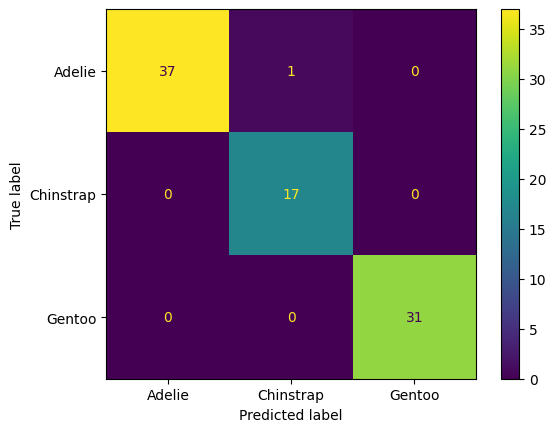

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_teste, predicao)

# Gráficos sugeridos

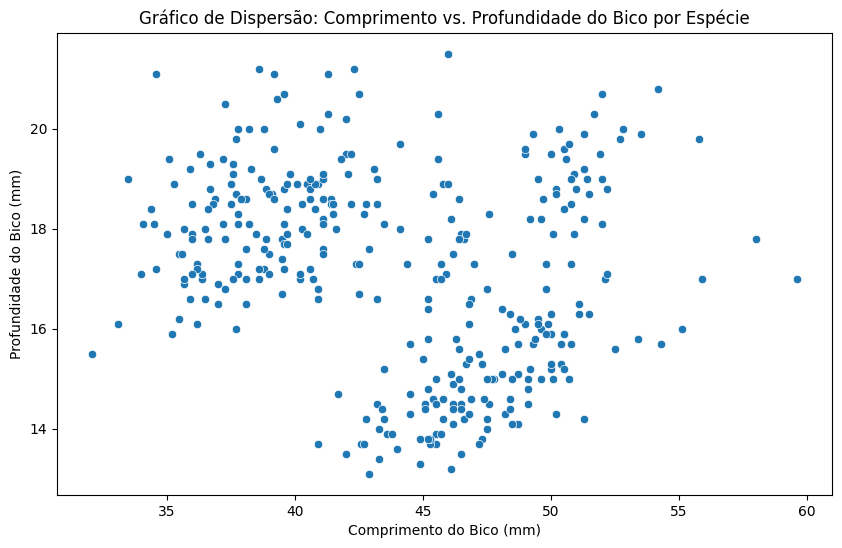

In [27]:
import matplotlib.pyplot as plt

# 1. Gráfico de dispersão de duas variáveis numéricas (com y original)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados, x="bill_length_mm", y="bill_depth_mm")
plt.title('Gráfico de Dispersão: Comprimento vs. Profundidade do Bico por Espécie')
plt.xlabel('Comprimento do Bico (mm)')
plt.ylabel('Profundidade do Bico (mm)')
plt.show()



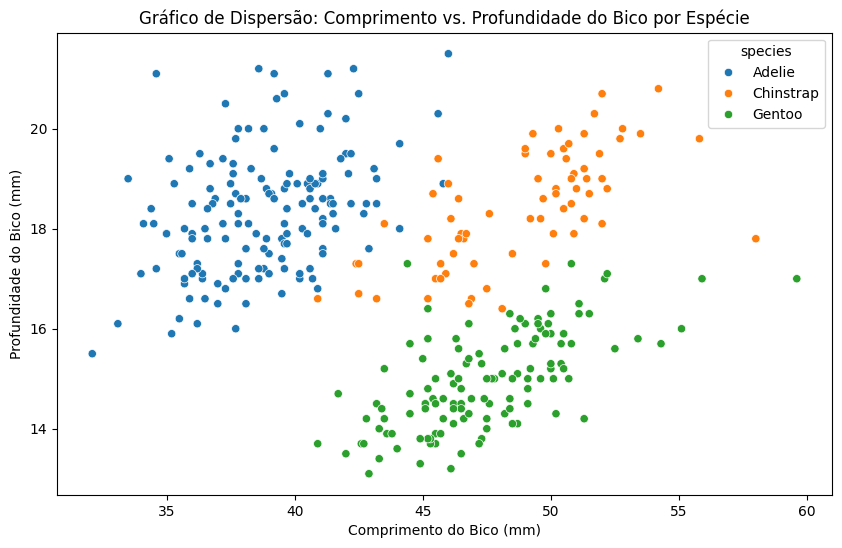

In [26]:
# 2. Gráfico de dispersão das mesmas variáveis em função das espécies (repetido, já feito acima)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.title('Gráfico de Dispersão: Comprimento vs. Profundidade do Bico por Espécie')
plt.xlabel('Comprimento do Bico (mm)')
plt.ylabel('Profundidade do Bico (mm)')
plt.show()

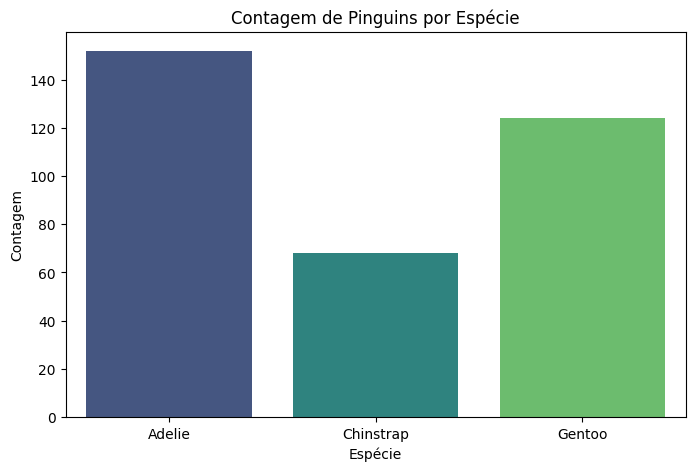

In [21]:
# 3. Gráfico de barras das espécies
plt.figure(figsize=(8, 5))
sns.countplot(data=dados, x="species", palette='viridis', hue="species", legend=False)
plt.title('Contagem de Pinguins por Espécie')
plt.xlabel('Espécie')
plt.ylabel('Contagem')
plt.show()


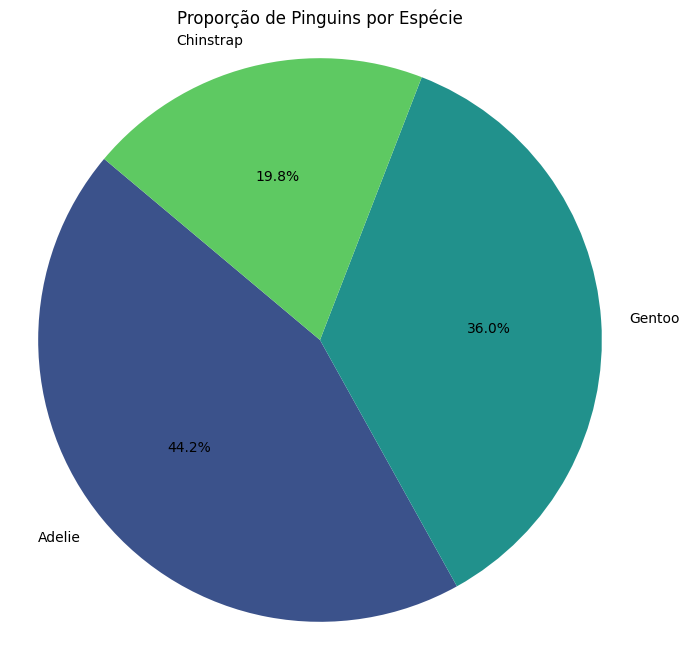

In [22]:

# 4. Gráfico de pizza das espécies
especies_counts = dados['species'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(especies_counts, labels=especies_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(especies_counts)))
plt.title('Proporção de Pinguins por Espécie')
plt.axis('equal')  # Garante que o círculo seja desenhado como um círculo.
plt.show()


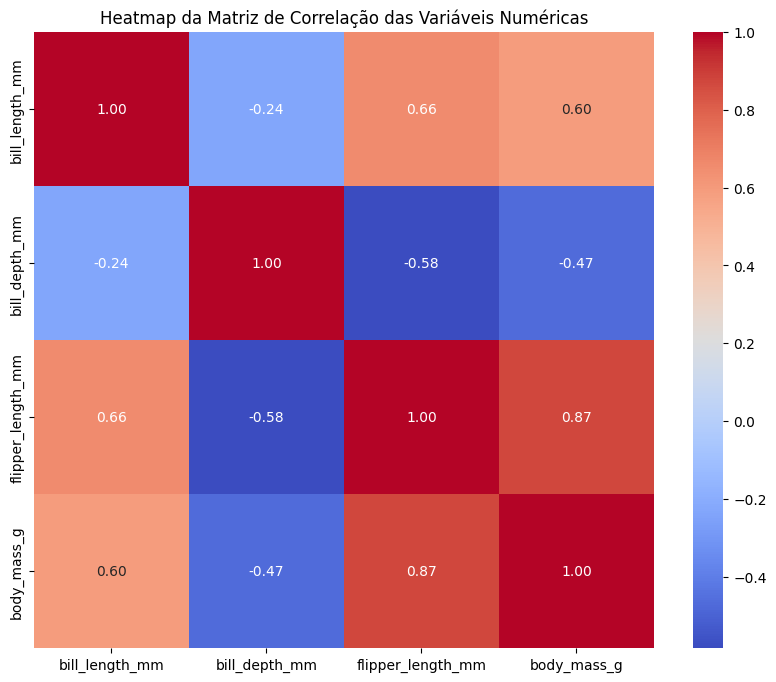

In [23]:

# 5. Heatmap (matriz de correlação das variáveis numéricas)
numerical_dados = dados.select_dtypes(include=['number'])
plt.figure(figsize=(10, 8))
sns.heatmap(numerical_dados.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap da Matriz de Correlação das Variáveis Numéricas')
plt.show()


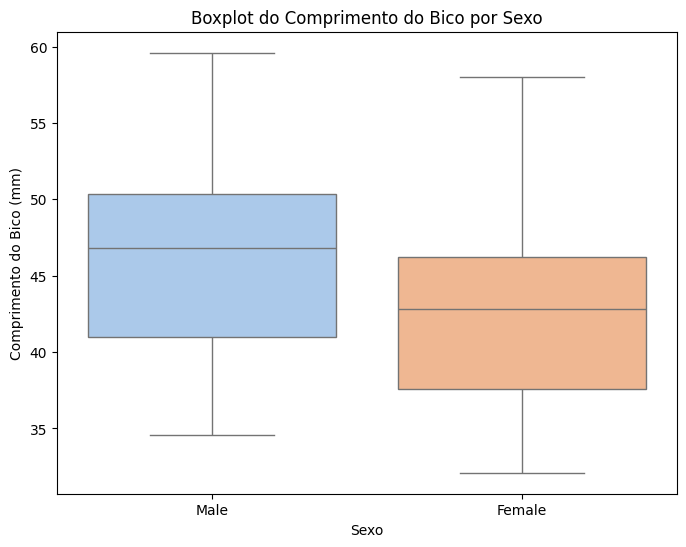

In [24]:

# 6. Boxplot de uma variável numérica em função do sexo
plt.figure(figsize=(8, 6))
sns.boxplot(data=dados, x="sex", y="bill_length_mm", palette='pastel', hue="sex", legend=False)
plt.title('Boxplot do Comprimento do Bico por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Comprimento do Bico (mm)')
plt.show()


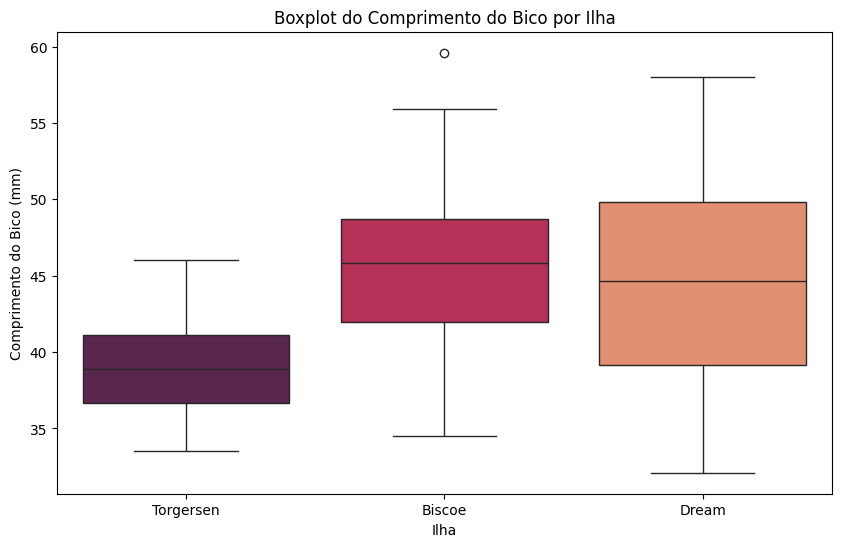

In [25]:

# 7. Boxplot de uma variável numérica em função da variável Island
plt.figure(figsize=(10, 6))
sns.boxplot(data=dados, x="island", y="bill_length_mm", palette='rocket', hue="island", legend=False)
plt.title('Boxplot do Comprimento do Bico por Ilha')
plt.xlabel('Ilha')
plt.ylabel('Comprimento do Bico (mm)')
plt.show()